In [ ]:
# import libraries
import pandas as pd

In [ ]:
# Read external file
df=pd.read_csv("/content/cars.csv")
df.head()

In [ ]:
# Check the number of rows and columns
df.shape

In [ ]:
# List of column headers from dataframe
df.columns

In [ ]:
# to check datatype of variable
type(df)

In [1]:
df['id'].dtype

NameError: name 'df' is not defined

In [ ]:
# check the info of dataset
df.info()

In [ ]:
# check the statistical details  (Descriptive Analysis)
df.describe()

In [ ]:
# check for null values
df.isnull().sum()

In [ ]:
# display columns
df.columns

In [ ]:
# Seggregate data in categorical and continuous type

categorical_df=df.select_dtypes(include='object')
continuous_df=df.select_dtypes(exclude='object')

# Display categorical values
categorical_df

In [ ]:
# display continuous values
continuous_df

In [ ]:
df.columns

In [ ]:
df['id'].dtype

In [ ]:
# seggregate columns based on datatype.
cat_list=[]
con_list=[]

for i in df.columns:
  if df[i].dtype=='object':
    cat_list.append(i)
  else:
    con_list.append(i)


In [ ]:
cat_list

In [ ]:
con_list

In [ ]:
df['AirBags'].dtype

In [45]:
df['AirBags'].mode()

,AirBags
0,Driver only


Handle Missing Values  Treating Missing Values

In [46]:
df['Origin'].mode()

,Origin
0,USA


In [ ]:
# Replacing single column
# df['AirBags'].fillna('Driver Only')

In [52]:
# Check for missing values  Air Bags = 37, rear Seat 2 Laguage =11
# interate through every column

for i in df.columns:
  if df[i].dtype=='object':
    # Categorical data will be replaced by mode
    modal_value=df[i].mode()[0]
    df[i]=df[i].fillna(modal_value)
  else:
    # continuous data will be replaced by
    mean_value=df[i].mean()
    df[i]=df[i].fillna(mean_value)

In [53]:
df.isnull().sum()

,0
id,0
Manufacturer,0
Model,0
Type,0
Min.Price,0
Price,0
Max.Price,0
MPG.city,0
MPG.highway,0
AirBags,0


# Analyse Data
unique() <br>
value_counts() <br>
nunique()


In [55]:
from datetime import date
today=date.today()
today

datetime.date(2025, 11, 2)

In [ ]:
# Unique()
df['AirBags'].unique()


In [ ]:
# value_counts()
df['AirBags'].value_counts()

In [ ]:
df['DriveTrain'].value_counts()

In [ ]:
df.value_counts('Origin')

In [ ]:
df['Rear.seat.room'].mean()

In [ ]:
df['Manufacturer'].unique()

In [ ]:
df['Manufacturer'].nunique()

In [ ]:
df['Manufacturer'].mode()[0]

In [56]:
# Display Count of Manufacturers
df['Manufacturer'].value_counts()

,count
Manufacturer,
Chevrolet,8
Ford,8
Dodge,6
Mazda,5
Pontiac,5
Oldsmobile,4
Hyundai,4
Buick,4
Nissan,4


# Libraries for Data Visualization
import seaborn as sns <br>
import matplotlib.pyplot as plt


# Univariate - Categorical Variable
Bar Chart

In [57]:
cat_list

['Manufacturer',
 'Model',
 'Type',
 'AirBags',
 'DriveTrain',
 'Cylinders',
 'Man.trans.avail',
 'Origin',
 'Make']

In [58]:
# Let's consider 'Type' as a categorical variable.
df['Type'].value_counts()


,count
Type,
Midsize,22
Small,21
Compact,16
Sporty,14
Large,11
Van,9


In [59]:
import matplotlib.pyplot as plt
import seaborn as sns

# Univariate - Categorical Variable
Pie Chart

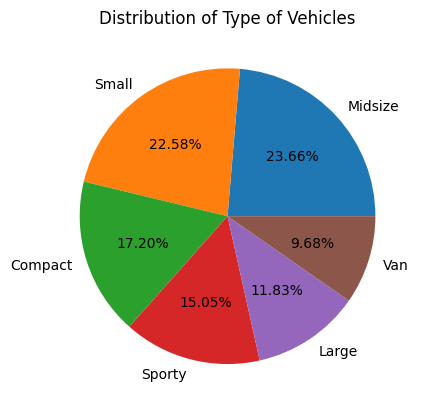

In [66]:
t=df['Type'].value_counts()
plt.pie(t,labels=t.index,autopct='%1.2f%%')
plt.title('Distribution of Type of Vehicles')
plt.show()

# Univariate - Categorical Variable
Count plot

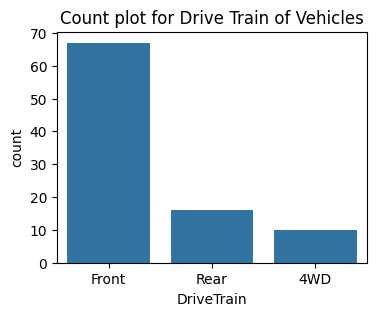

In [70]:
# Drive Train
plt.figure(figsize=(4,3))
sns.countplot(x='DriveTrain',data=df)
plt.title("Count plot for Drive Train of Vehicles")
plt.show()

# Univariate - Numeric Variable
Histogram

# Bivariate Analysis
## continuous vs continous
### Scatter Plot

In [71]:
df['EngineSize'].describe()

,EngineSize
count,93.000000
mean,2.667742
std,1.037363
min,1.000000
25%,1.800000
50%,2.400000
75%,3.300000
max,5.700000


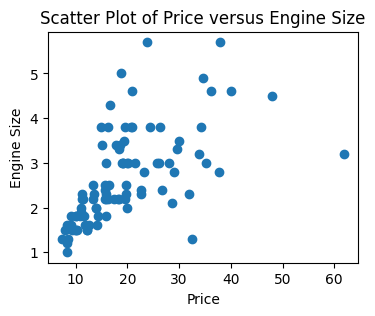

In [74]:
plt.figure(figsize=(4,3))
plt.scatter(df['Price'],df['EngineSize'])
plt.xlabel('Price')
plt.ylabel('Engine Size')
plt.title('Scatter Plot of Price versus Engine Size')
plt.show()

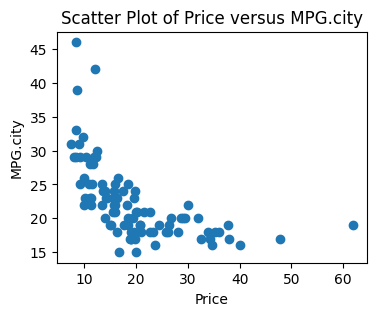

In [82]:
plt.figure(figsize=(4,3))
plt.scatter(df['Price'],df['MPG.city'])
plt.xlabel('Price')
plt.ylabel('MPG.city')
plt.title('Scatter Plot of Price versus MPG.city')
plt.show()

# Correlation


In [76]:
df[['Price','EngineSize']].corr()

,Price,EngineSize
Price,1.000000,0.597425
EngineSize,0.597425,1.000000


In [ ]:
continuous_df.corr()

In [80]:
df[['Price','EngineSize','Horsepower','MPG.city']].corr()

,Price,EngineSize,Horsepower,MPG.city
Price,1.000000,0.597425,0.788218,-0.594562
EngineSize,0.597425,1.000000,0.732120,-0.710003
Horsepower,0.788218,0.732120,1.000000,-0.672636
MPG.city,-0.594562,-0.710003,-0.672636,1.000000


# Categorical vs. Continuous Analysis:
Box Plot

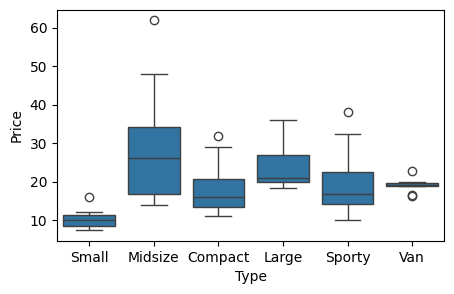

In [101]:
# Type of vehicle and Price
plt.figure(figsize=(5,3))
sns.boxplot(x='Type',y='Price',data=df)
plt.show()

# Categorical vs Categorical
Cross Tab , Heatmap

In [83]:
cat_list

['Manufacturer',
 'Model',
 'Type',
 'AirBags',
 'DriveTrain',
 'Cylinders',
 'Man.trans.avail',
 'Origin',
 'Make']

<Axes: xlabel='Origin', ylabel='Manufacturer'>

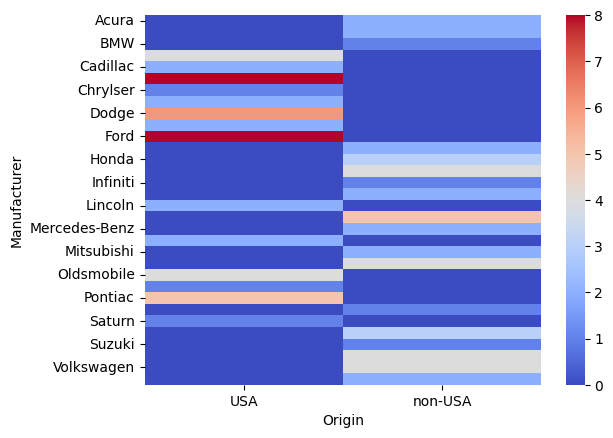

In [96]:
mtb=pd.crosstab(df['Manufacturer'],df['Origin'])
sns.heatmap(mtb,cmap='coolwarm')

In [89]:
ctb=pd.crosstab(df['Type'],df['Origin'])
ctb

Origin,USA,non-USA
Type,,
Compact,7,9
Large,11,0
Midsize,10,12
Small,7,14
Sporty,8,6
Van,5,4


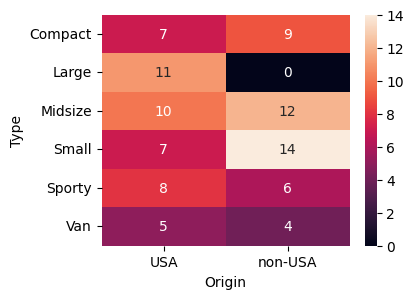

In [93]:
plt.figure(figsize=(4,3))
sns.heatmap(ctb,annot=True)
plt.show()

# Multivariate Analysis
pairplot

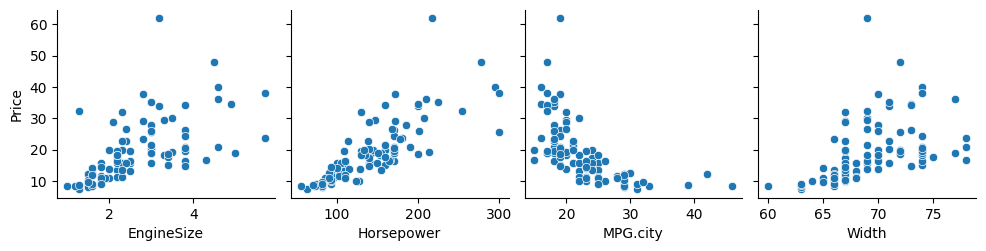

In [103]:
sns.pairplot(df,y_vars='Price',x_vars=['EngineSize','Horsepower','MPG.city','Width'])